# Practical Pair Trading

- Set a maximum holding period based on the half-life. A common heuristic in the literature (e.g., Vidyamurthy) is:$$T_{max} = 2 \times t_{1/2}$$If the spread has not reverted by $T_{max}$, the "spring" is likely broken (a structural break has occurred). Holding further increases your exposure to the "First-Passage to Infinity" (divergence).

- The Sharpe Ratio Maximization:The annualized Sharpe Ratio of a mean-reverting strategy is a function of $\theta$. Higher $\theta$ (shorter half-life) allows for more "round-trips" per year, increasing the numerator of the Sharpe Ratio.$$\text{Expected Annual Trades} \approx \frac{252}{t_{1/2} + \text{Wait Time}}$$

[*********************100%***********************]  2 of 2 completed


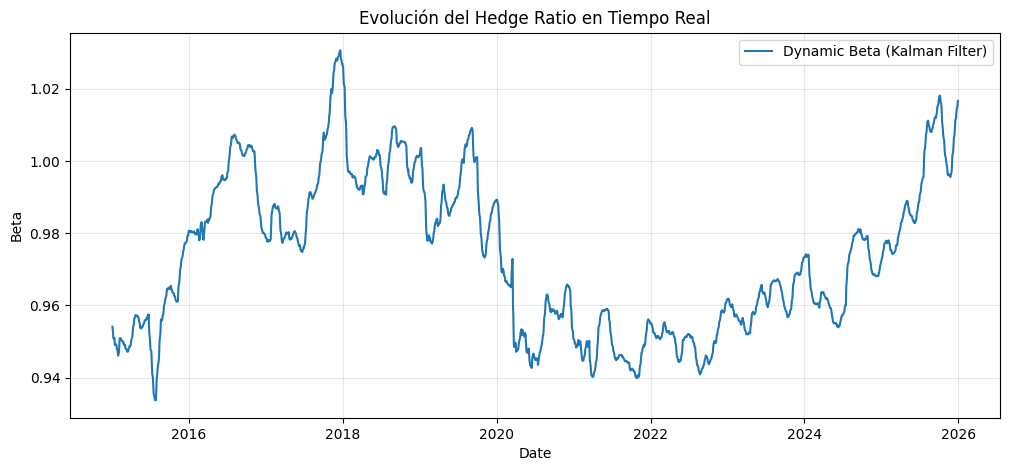

In [13]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import statsmodels.api as sm

def kalman_filter_pair_trading(ticker_A, ticker_B, start, end):
    # 1. Obtención de datos
    data = yf.download([ticker_A, ticker_B], start=start, end=end, auto_adjust=False)['Adj Close'].dropna()
    x = np.log(data[ticker_B].values)
    y = np.log(data[ticker_A].values)

    # 2. Inicialización de variables del Filtro de Kalman
    # Warm-up: Usar OLS para inicializar el estado (evita singularidad en t=0)
    X_warmup = sm.add_constant(x[:60])  # First 60 points for warm-up
    model_warmup = sm.OLS(y[:60], X_warmup).fit()
    initial_beta = model_warmup.params[1]
    initial_alpha = model_warmup.params[0]
    
    state_means = np.array([initial_beta, initial_alpha])
    # Incertidumbre inicial (Covarianza del estado)
    state_cov = np.eye(2) * 0.1
    
    # Parámetros de ruido (Hiperparámetros)
    # Q: Covarianza del proceso (qué tan rápido cambian beta y alpha)
    # R: Covarianza de la medición (ruido en los precios)
    Q = 1e-5 * np.eye(2)
    R = 0.01
    
    betas = []
    alphas = []
    spreads = []

    # 3. Bucle del Filtro (Online Learning)
    for t in range(len(y)):
        # --- PASO DE PREDICCIÓN ---
        # El estado esperado es igual al anterior (Paseo Aleatorio)
        # La covarianza aumenta por el ruido del proceso Q
        state_cov = state_cov + Q
        
        # --- PASO DE ACTUALIZACIÓN ---
        # Vector de observación H (los datos del activo B hoy)
        H = np.array([x[t], 1.0])
        
        # Innovación (Error de predicción)
        prediction = np.dot(H, state_means)
        innovation = y[t] - prediction
        
        # Covarianza de la innovación
        innovation_cov = np.dot(H, np.dot(state_cov, H.T)) + R
        
        # Ganancia de Kalman (K)
        K = np.dot(state_cov, H.T) / innovation_cov
        
        # Actualizar estado e incertidumbre
        state_means = state_means + K * innovation
        state_cov = state_cov - np.outer(K, np.dot(H, state_cov))
        
        # Guardar resultados
        betas.append(state_means[0])
        alphas.append(state_means[1])
        spreads.append(innovation) # El spread es la innovación/error

    # 4. Resultados
    results = pd.DataFrame(index=data.index)
    results['beta'] = betas
    results['alpha'] = alphas
    results['spread'] = spreads
    
    return results

# Ejecución
kf_results = kalman_filter_pair_trading('DHI', 'LEN', '2015-01-01', '2026-01-01')

# Visualización del Hedge Ratio Dinámico
plt.figure(figsize=(12, 5))
plt.plot(kf_results.index, kf_results['beta'], label='Dynamic Beta (Kalman Filter)')
plt.title('Evolución del Hedge Ratio en Tiempo Real')
plt.ylabel('Beta')
plt.xlabel('Date')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

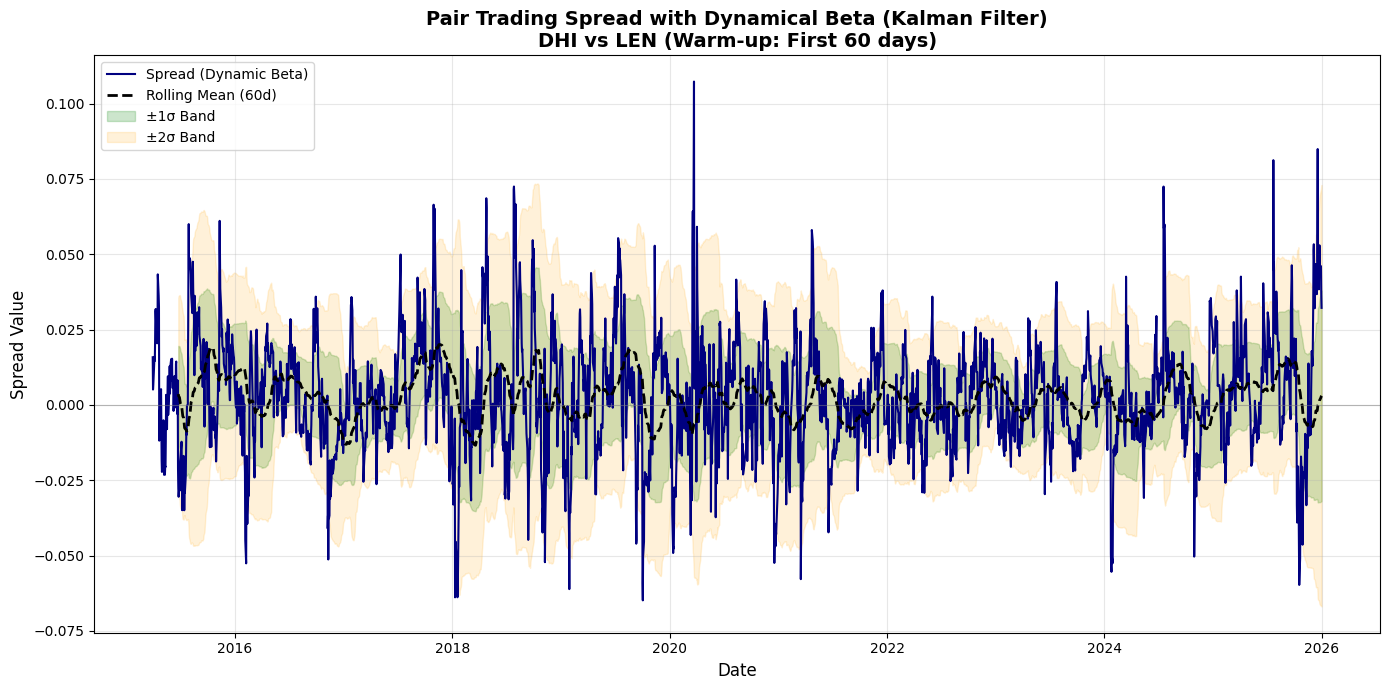

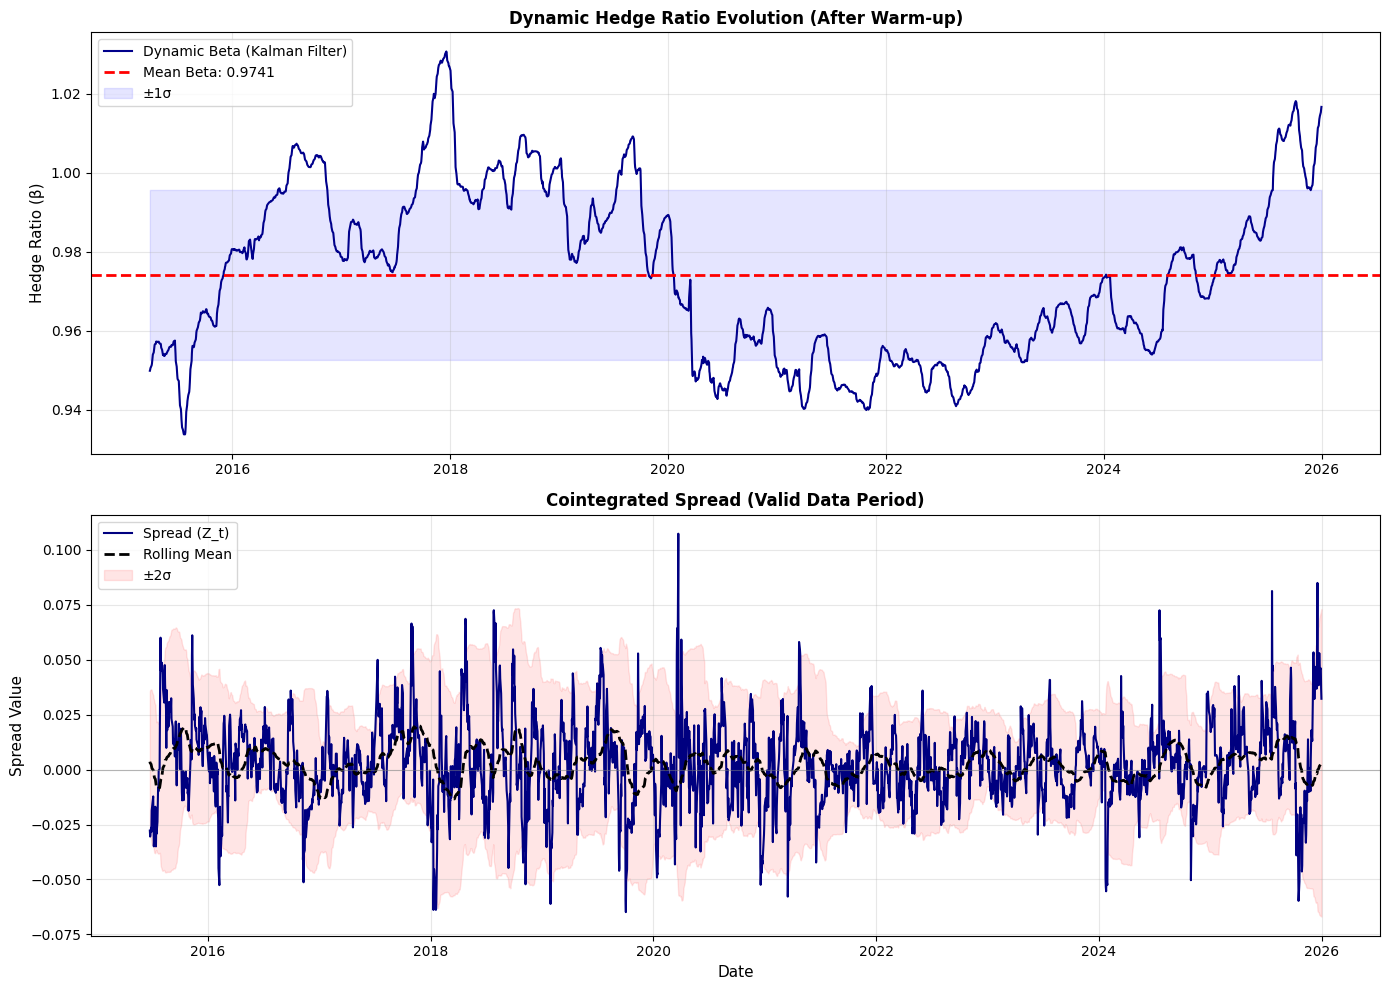

In [14]:
# Plot the spread with dynamic beta from Kalman Filter
# Skip the warm-up period (first 60 days) to avoid singularities
warmup_days = 60

plt.figure(figsize=(14, 7))

# Main spread plot (skip warm-up)
plt.plot(kf_results.index[warmup_days:], kf_results['spread'].iloc[warmup_days:], 
         color='navy', linewidth=1.5, label='Spread (Dynamic Beta)')

# Calculate rolling statistics for the spread (after warm-up)
window_stats = 60
kf_results['spread_mean'] = kf_results['spread'].rolling(window=window_stats).mean()
kf_results['spread_std'] = kf_results['spread'].rolling(window=window_stats).std()

# Plot mean and confidence bands (skip warm-up + window)
min_valid_idx = warmup_days + window_stats
plt.plot(kf_results.index[min_valid_idx:], kf_results['spread_mean'].iloc[min_valid_idx:], 
         color='black', linestyle='--', linewidth=2, label='Rolling Mean (60d)')

plt.fill_between(kf_results.index[min_valid_idx:], 
                 (kf_results['spread_mean'] - kf_results['spread_std']).iloc[min_valid_idx:], 
                 (kf_results['spread_mean'] + kf_results['spread_std']).iloc[min_valid_idx:], 
                 color='green', alpha=0.2, label='±1σ Band')

plt.fill_between(kf_results.index[min_valid_idx:], 
                 (kf_results['spread_mean'] - 2*kf_results['spread_std']).iloc[min_valid_idx:], 
                 (kf_results['spread_mean'] + 2*kf_results['spread_std']).iloc[min_valid_idx:], 
                 color='orange', alpha=0.15, label='±2σ Band')

# Plot bands as lines
plt.axhline(0, color='gray', linestyle='-', linewidth=0.8, alpha=0.5)

plt.xlabel('Date', fontsize=12)
plt.ylabel('Spread Value', fontsize=12)
plt.title('Pair Trading Spread with Dynamical Beta (Kalman Filter)\nDHI vs LEN (Warm-up: First 60 days)', 
          fontsize=14, fontweight='bold')
plt.legend(loc='best', fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Plot the dynamic beta evolution on a separate panel
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10))

# Panel 1: Dynamic Beta (skip warm-up)
ax1.plot(kf_results.index[warmup_days:], kf_results['beta'].iloc[warmup_days:], 
         color='darkblue', linewidth=1.5, label='Dynamic Beta (Kalman Filter)')
ax1.axhline(kf_results['beta'].iloc[warmup_days:].mean(), color='red', linestyle='--', 
            linewidth=2, label=f'Mean Beta: {kf_results["beta"].iloc[warmup_days:].mean():.4f}')
ax1.fill_between(kf_results.index[warmup_days:], 
                 kf_results['beta'].iloc[warmup_days:].mean() - kf_results['beta'].iloc[warmup_days:].std(), 
                 kf_results['beta'].iloc[warmup_days:].mean() + kf_results['beta'].iloc[warmup_days:].std(), 
                 color='blue', alpha=0.1, label='±1σ')
ax1.set_ylabel('Hedge Ratio (β)', fontsize=11)
ax1.set_title('Dynamic Hedge Ratio Evolution (After Warm-up)', fontsize=12, fontweight='bold')
ax1.legend(loc='best')
ax1.grid(True, alpha=0.3)

# Panel 2: Spread with Dynamic Beta (skip warm-up + window)
ax2.plot(kf_results.index[min_valid_idx:], kf_results['spread'].iloc[min_valid_idx:], 
         color='navy', linewidth=1.5, label='Spread (Z_t)')
ax2.plot(kf_results.index[min_valid_idx:], kf_results['spread_mean'].iloc[min_valid_idx:], 
         color='black', linestyle='--', linewidth=2, label='Rolling Mean')
ax2.fill_between(kf_results.index[min_valid_idx:], 
                 (kf_results['spread_mean'] - 2*kf_results['spread_std']).iloc[min_valid_idx:], 
                 (kf_results['spread_mean'] + 2*kf_results['spread_std']).iloc[min_valid_idx:], 
                 color='red', alpha=0.1, label='±2σ')
ax2.axhline(0, color='gray', linestyle='-', linewidth=0.8, alpha=0.5)
ax2.set_xlabel('Date', fontsize=11)
ax2.set_ylabel('Spread Value', fontsize=11)
ax2.set_title('Cointegrated Spread (Valid Data Period)', fontsize=12, fontweight='bold')
ax2.legend(loc='best')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [5]:
import numpy as np
import pandas as pd
import yfinance as yf
import statsmodels.api as sm

def backtest_pair_trading(ticker_A, ticker_B, start, end, window=60, entry_z=2.0, exit_z=0, cost=0.001):
    # 1. Descarga y preparación
    data = yf.download([ticker_A, ticker_B], start=start, end=end, auto_adjust=False)['Adj Close'].dropna()
    log_prices = np.log(data)
    
    # DataFrame para resultados
    results = pd.DataFrame(index=log_prices.index)
    results['log_A'] = log_prices[ticker_A]
    results['log_B'] = log_prices[ticker_B]
    
    #Use kalman filter para obtener beta dinámico
    kf_results = kalman_filter_pair_trading(ticker_A, ticker_B, start, end)
    betas = kf_results['beta'].values
    spreads = kf_results['spread'].values

    results['beta'] = betas
    results['spread'] = spreads
    
    # 3. Normalización (Z-Score)
    results['mean'] = results['spread'].rolling(window=window).mean()
    results['std'] = results['spread'].rolling(window=window).std()
    results['z_score'] = (results['spread'] - results['mean']) / results['std']
    
    # 4. Lógica de Trading (Vectorizada)
    # Posición: 1 (Long Spread), -1 (Short Spread), 0 (Neutral)
    results['position'] = 0
    curr_pos = 0
    positions = []
    
    for z in results['z_score']:
        if np.isnan(z):
            positions.append(0)
            continue
        
        if curr_pos == 0:
            if z > entry_z: curr_pos = -1 # Short A, Long B
            elif z < -entry_z: curr_pos = 1 # Long A, Short B
        elif curr_pos == 1 and z >= exit_z:
            curr_pos = 0 # Cerrar Long
        elif curr_pos == -1 and z <= exit_z:
            curr_pos = 0 # Cerrar Short
            
        positions.append(curr_pos)
    
    results['position'] = positions
    
    # 5. Cálculo de Retornos
    # Retorno del spread = d(Spread)
    # Nota: Simplificación para propósitos académicos
    results['returns_A'] = results['log_A'].diff()
    results['returns_B'] = results['log_B'].diff()
    
    # Retorno estrategia = Posicion_t-1 * (Ret_A - Beta * Ret_B)
    results['strategy_ret'] = results['position'].shift(1) * (results['returns_A'] - results['beta'] * results['returns_B'])
    
    # Aplicar costes de transacción (cuando la posición cambia)
    trades = results['position'].diff().fillna(0) != 0
    results['strategy_ret'] = results['strategy_ret'] - (trades * cost)
    
    # 6. Métricas
    cum_ret = results['strategy_ret'].cumsum().apply(np.exp)
    sharpe = (results['strategy_ret'].mean() / results['strategy_ret'].std()) * np.sqrt(252)
    
    return results, sharpe, cum_ret

# Ejemplo práctico
res, sharpe, equity = backtest_pair_trading('DHI', 'LEN', '2000-01-01', '2026-01-01')
print(f"Sharpe Ratio del Backtest: {sharpe:.2f}")

[*********************100%***********************]  2 of 2 completed
[*********************100%***********************]  2 of 2 completed

Sharpe Ratio del Backtest: 0.38
